# Small Neural Network from Scratch

In this notebook, I build a small neural network with:

- 2 input features
- 2 hidden neurons
- 1 output neuron

The goal is to understand how information flows through multiple neurons.

In [1]:
x1 = 1
x2 = 2

# Hidden neuron 1
w11 = 0.5
w12 = -0.2
b1 = 0.1

# Hidden neuron 2
w21 = -0.3
w22 = 0.8
b2 = -0.1

In [2]:
def relu(z):
    return max(0, z)

In [3]:
z1 = w11 * x1 + w12 * x2 + b1
h1 = relu(z1)

z2 = w21 * x1 + w22 * x2 + b2
h2 = relu(z2)

print("z1 =", z1)
print("h1 =", h1)

print("z2 =", z2)
print("h2 =", h2)

z1 = 0.19999999999999998
h1 = 0.19999999999999998
z2 = 1.2
h2 = 1.2


In [4]:
# Output neuron
w31 = 0.7
w32 = -0.5
b3 = 0.2

z3 = w31 * h1 + w32 * h2 + b3

y_pred = z3

print("z3 =", z3)
print("prediction =", y_pred)

z3 = -0.25999999999999995
prediction = -0.25999999999999995


In [5]:
y = 1

loss = 0.5 * (y - y_pred) ** 2

print("loss =", loss)

loss = 0.7938000000000001


In [6]:
# Gradient from loss to prediction
dL_dy = y_pred - y

# Output layer gradients
grad_w31 = dL_dy * h1
grad_w32 = dL_dy * h2
grad_b3 = dL_dy

print("grad_w31 =", grad_w31)
print("grad_w32 =", grad_w32)
print("grad_b3 =", grad_b3)

grad_w31 = -0.252
grad_w32 = -1.512
grad_b3 = -1.26


In [7]:
# Gradient flowing back to hidden neurons
dL_dh1 = dL_dy * w31
dL_dh2 = dL_dy * w32

print("dL/dh1 =", dL_dh1)
print("dL/dh2 =", dL_dh2)

dL/dh1 = -0.8819999999999999
dL/dh2 = 0.63


In [8]:
relu_grad_z1 = 1 if z1 > 0 else 0
relu_grad_z2 = 1 if z2 > 0 else 0

dL_dz1 = dL_dh1 * relu_grad_z1
dL_dz2 = dL_dh2 * relu_grad_z2

print("dL/dz1 =", dL_dz1)
print("dL/dz2 =", dL_dz2)

dL/dz1 = -0.8819999999999999
dL/dz2 = 0.63


In [9]:
grad_w11 = dL_dz1 * x1
grad_w12 = dL_dz1 * x2
grad_b1 = dL_dz1

grad_w21 = dL_dz2 * x1
grad_w22 = dL_dz2 * x2
grad_b2 = dL_dz2

print("grad_w11 =", grad_w11)
print("grad_w12 =", grad_w12)
print("grad_b1 =", grad_b1)

print("grad_w21 =", grad_w21)
print("grad_w22 =", grad_w22)
print("grad_b2 =", grad_b2)


grad_w11 = -0.8819999999999999
grad_w12 = -1.7639999999999998
grad_b1 = -0.8819999999999999
grad_w21 = 0.63
grad_w22 = 1.26
grad_b2 = 0.63


In [10]:
learning_rate = 0.1

# Update hidden layer
w11 = w11 - learning_rate * grad_w11
w12 = w12 - learning_rate * grad_w12
b1 = b1 - learning_rate * grad_b1

w21 = w21 - learning_rate * grad_w21
w22 = w22 - learning_rate * grad_w22
b2 = b2 - learning_rate * grad_b2

# Update output layer
w31 = w31 - learning_rate * grad_w31
w32 = w32 - learning_rate * grad_w32
b3 = b3 - learning_rate * grad_b3

In [11]:
# Forward again after updating weights

z1 = w11 * x1 + w12 * x2 + b1
h1 = relu(z1)

z2 = w21 * x1 + w22 * x2 + b2
h2 = relu(z2)

z3 = w31 * h1 + w32 * h2 + b3
y_pred = z3

new_loss = 0.5 * (y - y_pred) ** 2

print("new prediction =", y_pred)
print("new loss =", new_loss)

new prediction = 0.56810224
new loss = 0.0932678375465088


## Training the Small Neural Network

Now we train the whole network for multiple epochs.

Each epoch includes:

1. Forward pass
2. Loss calculation
3. Backpropagation
4. Gradient descent update

In [12]:
x1 = 1
x2 = 2
y = 1

# Hidden neuron 1
w11 = 0.5
w12 = -0.2
b1 = 0.1

# Hidden neuron 2
w21 = -0.3
w22 = 0.8
b2 = -0.1

# Output neuron
w31 = 0.7
w32 = -0.5
b3 = 0.2

learning_rate = 0.1

loss_history = []

In [13]:
for epoch in range(20):

    # ---------- Forward ----------
    z1 = w11 * x1 + w12 * x2 + b1
    h1 = relu(z1)

    z2 = w21 * x1 + w22 * x2 + b2
    h2 = relu(z2)

    z3 = w31 * h1 + w32 * h2 + b3
    y_pred = z3

    # ---------- Loss ----------
    loss = 0.5 * (y - y_pred) ** 2
    loss_history.append(loss)

    # ---------- Backprop: output layer ----------
    dL_dy = y_pred - y

    grad_w31 = dL_dy * h1
    grad_w32 = dL_dy * h2
    grad_b3 = dL_dy

    # ---------- Backprop: hidden layer ----------
    dL_dh1 = dL_dy * w31
    dL_dh2 = dL_dy * w32

    dL_dz1 = dL_dh1 * (1 if z1 > 0 else 0)
    dL_dz2 = dL_dh2 * (1 if z2 > 0 else 0)

    grad_w11 = dL_dz1 * x1
    grad_w12 = dL_dz1 * x2
    grad_b1 = dL_dz1

    grad_w21 = dL_dz2 * x1
    grad_w22 = dL_dz2 * x2
    grad_b2 = dL_dz2

    # ---------- Gradient Descent ----------
    w11 -= learning_rate * grad_w11
    w12 -= learning_rate * grad_w12
    b1 -= learning_rate * grad_b1

    w21 -= learning_rate * grad_w21
    w22 -= learning_rate * grad_w22
    b2 -= learning_rate * grad_b2

    w31 -= learning_rate * grad_w31
    w32 -= learning_rate * grad_w32
    b3 -= learning_rate * grad_b3

    print(
        "Epoch:", epoch + 1,
        "Prediction:", round(y_pred, 4),
        "Loss:", round(loss, 6)
    )

Epoch: 1 Prediction: -0.26 Loss: 0.7938
Epoch: 2 Prediction: 0.5681 Loss: 0.093268
Epoch: 3 Prediction: 0.834 Loss: 0.013784
Epoch: 4 Prediction: 0.941 Loss: 0.00174
Epoch: 5 Prediction: 0.98 Loss: 0.000199
Epoch: 6 Prediction: 0.9934 Loss: 2.2e-05
Epoch: 7 Prediction: 0.9978 Loss: 2e-06
Epoch: 8 Prediction: 0.9993 Loss: 0.0
Epoch: 9 Prediction: 0.9998 Loss: 0.0
Epoch: 10 Prediction: 0.9999 Loss: 0.0
Epoch: 11 Prediction: 1.0 Loss: 0.0
Epoch: 12 Prediction: 1.0 Loss: 0.0
Epoch: 13 Prediction: 1.0 Loss: 0.0
Epoch: 14 Prediction: 1.0 Loss: 0.0
Epoch: 15 Prediction: 1.0 Loss: 0.0
Epoch: 16 Prediction: 1.0 Loss: 0.0
Epoch: 17 Prediction: 1.0 Loss: 0.0
Epoch: 18 Prediction: 1.0 Loss: 0.0
Epoch: 19 Prediction: 1.0 Loss: 0.0
Epoch: 20 Prediction: 1.0 Loss: 0.0


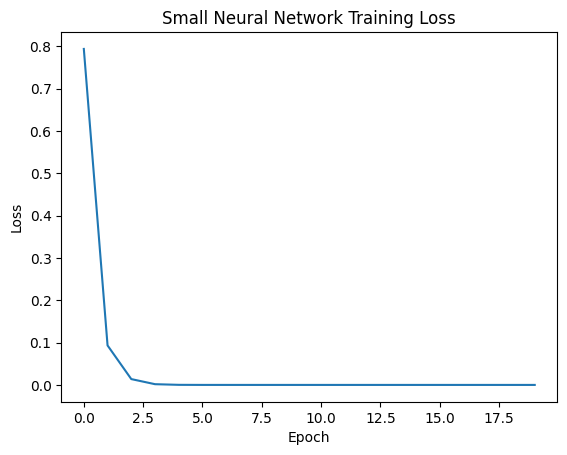

In [14]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Small Neural Network Training Loss")

plt.show()